# BERT polarization classifier

## 0. Imports and seeds

In [1]:
#@title Imports
import os
import random
from sklearn.metrics import roc_curve, auc
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import transformers
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer, BertModel, BertConfig, PreTrainedModel,
    DataCollatorWithPadding, TrainingArguments, Trainer, TrainerCallback,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers.utils import logging as hf_logging
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

hf_logging.set_verbosity_error()

In [2]:
#@title Seed and device
seed = 123
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def get_device():
    if torch.cuda.is_available():
        dev = torch.device("cuda")
        print(f"[device] CUDA active -> {torch.cuda.get_device_name(0)}")
    elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        dev = torch.device("mps")
        print("[device] Apple MPS active")
    else:
        dev = torch.device("cpu")
        print("[device] No GPU found -> CPU (BERT will be slow)")
    return dev

device = get_device()
print(f"[versions] torch={torch.__version__} | transformers={transformers.__version__} | CUDA build={torch.version.cuda}")

[device] CUDA active -> Tesla T4
[versions] torch=2.11.0+cu128 | transformers=5.12.1 | CUDA build=12.8


## 1. Load data, pick text column, brief composition analysis

In [3]:
#@title Load data
#Per github
CSV_PATH = r"..\Dati\Processed\dataset_processed_quantile1_sentences.csv"
TEST_CSV_PATH = r"..\Dati\Processed\test_holdout_processed.csv"

#Per google colab
#CSV_PATH = r"/content/dataset_processed_quantile1_sentences.csv"
#TEST_CSV_PATH = r"/content/test_holdout_processed.csv"

MODEL_NAME = "bert-base-cased"   #casing/punctuation are a stylistic (polarization) signal

ID_COLS_TRAIN = ["article_id", "topic_id", "binary_label", "fold"]
ID_COLS_TEST  = ["article_id", "topic_id", "binary_label"]


TEXT_COL_TO_USE = "text_bert"

def load_frame(csv_path, id_cols, label, has_fold):
    df_raw = pd.read_csv(csv_path)
    text_col = TEXT_COL_TO_USE

    if text_col not in df_raw.columns:
        raise ValueError(
            f"[{label}] Expected text column '{text_col}' not found in CSV. "
            f"Actual columns in CSV: {list(df_raw.columns)}"
        )

    missing_id_cols = [c for c in id_cols if c not in df_raw.columns]
    if missing_id_cols:
        raise ValueError(f"[{label}] Missing expected id/label columns: {missing_id_cols}")

    out = df_raw[id_cols + [text_col]].copy().reset_index(drop=True)
    out = out.rename(columns={text_col: "source_text"})
    if not has_fold:
        out["fold"] = -1   #placeholder: downstream code expects a 'fold' column, but it is

    print(f"[{label}] [text column] using '{text_col}'")
    print(f"[{label}] [shape] {out.shape[0]} docs, {out.shape[1]} cols")
    print(f"[{label}] [NaN]:\n{out.isna().sum().to_string()}")
    print(f"[{label}] [duplicated articles count] {out['article_id'].duplicated().sum()}")
    label_balance = out["binary_label"].value_counts(normalize=True).round(3).to_dict()
    print(f"[{label}] [label balance overall]: {label_balance}")
    return out, text_col

#Train/val set: used for grid search (k-fold CV over 'fold') and the final fit ----
print("--- TRAIN SET ---")
df, TEXT_COL = load_frame(CSV_PATH, ID_COLS_TRAIN, label="train", has_fold=True)

print("\n--- TRAIN SET (folds) ---")
print(f"[train] [folds] {[int(x) for x in sorted(df['fold'].unique())]}")
print("[train] [label balance per fold]")
print(df.groupby("fold")["binary_label"].value_counts(normalize=True).round(2).unstack())
docs_per_fold = df["fold"].value_counts().sort_index().to_dict()
print(f"[train] [docs per fold] {docs_per_fold}")

#Test
print("\n--- TEST SET ---")
df_test, TEXT_COL_TEST = load_frame(TEST_CSV_PATH, ID_COLS_TEST, label="test", has_fold=False)


--- TRAIN SET ---
[train] [text column] using 'text_bert'
[train] [shape] 978 docs, 5 cols
[train] [NaN]:
article_id      0
topic_id        0
binary_label    0
fold            0
source_text     0
[train] [duplicated articles count] 0
[train] [label balance overall]: {1: 0.667, 0: 0.333}

--- TRAIN SET (folds) ---
[train] [folds] [0, 1, 2, 3, 4]
[train] [label balance per fold]
binary_label     0     1
fold                    
0             0.33  0.67
1             0.33  0.67
2             0.33  0.67
3             0.33  0.67
4             0.33  0.67
[train] [docs per fold] {0: 195, 1: 195, 2: 198, 3: 195, 4: 195}

--- TEST SET ---
[test] [text column] using 'text_bert'
[test] [shape] 246 docs, 5 cols
[test] [NaN]:
article_id      0
topic_id        0
binary_label    0
source_text     0
fold            0
[test] [duplicated articles count] 0
[test] [label balance overall]: {1: 0.667, 0: 0.333}


## 2. Token-length profile: decide if a sliding window is needed

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

  > 128 tokens: 75.7% of docs
  > 256 tokens: 39.8% of docs
  > 384 tokens: 17.1% of docs
  > 512 tokens: 6.6% of docs

[decision] 6.6% of docs still exceed 512 tokens -> sliding window ENABLED


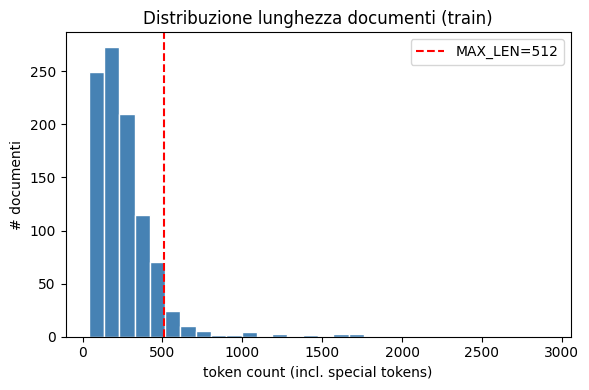

In [4]:
#@title Analysis for sliding window
MAX_LEN = 512

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok_lens = df["source_text"].apply(lambda t: len(tok(t, add_special_tokens=True)["input_ids"]))
df["_tok_len"] = tok_lens

for thr in (128, 256, 384, 512):
    share = (tok_lens > thr).mean()
    print(f"  > {thr} tokens: {share:.1%} of docs")

OVERFLOW_SHARE = (tok_lens > MAX_LEN).mean()
NEED_SLIDING_WINDOW = OVERFLOW_SHARE > 0.05
print(f"\n[decision] {OVERFLOW_SHARE:.1%} of docs still exceed {MAX_LEN} tokens -> "
      f"sliding window {'ENABLED' if NEED_SLIDING_WINDOW else 'not needed (plain truncation is enough)'}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(tok_lens, bins=30, color="steelblue", edgecolor="white")
ax.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN={MAX_LEN}")
ax.set_xlabel("token count (incl. special tokens)")
ax.set_ylabel("# documenti")
ax.set_title("Distribuzione lunghezza documenti (train)")
ax.legend()
plt.tight_layout()
plt.show()

If `NEED_SLIDING_WINDOW` is `True`. Each overflowing document is split into overlapping chunks (each chunk becomes its own training example, inheriting the parent label — a form of data augmentation for long docs); at eval time chunk-level probabilities for the same `article_id` are averaged back together before scoring, so metrics are still computed at the article level, not the chunk level.

In [5]:
#@title Chunks
def chunk_encode(text, tokenizer, max_len=MAX_LEN, stride=64, max_chunks=2):
    """Overlapping-window tokenization for one document."""
    ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    if not ids:
        return [tokenizer(text, truncation=True, max_length=max_len)]
    cls_id, sep_id = tokenizer.cls_token_id, tokenizer.sep_token_id
    window = max_len - 2  # leave room for [CLS]/[SEP]
    chunks, start = [], 0
    while start < len(ids) and len(chunks) < max_chunks:
        piece = ids[start:start + window]
        input_ids = [cls_id] + piece + [sep_id]
        enc = {
            "input_ids": input_ids,
            "attention_mask": [1] * len(input_ids),
            "token_type_ids": [0] * len(input_ids),
        }
        chunks.append(enc)
        if start + window >= len(ids):
            break
        start += window - stride
    return chunks

def build_examples(frame, tokenizer, max_len=MAX_LEN, use_sliding_window=False, stride=64, max_chunks=2):
    '''Row -> one or more model-ready examples. Always groupable back by article_id.'''
    records = []
    for row in frame.itertuples(index=False):
        text = row.source_text
        n_tokens = len(tokenizer(text, add_special_tokens=True)["input_ids"])
        if use_sliding_window and n_tokens > max_len:
            encs = chunk_encode(text, tokenizer, max_len=max_len, stride=stride, max_chunks=max_chunks)
        else:
            encs = [tokenizer(text, truncation=True, max_length=max_len)]
        for enc in encs:
            rec = {
                "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"],
                "labels": int(row.binary_label),
                "fold": int(row.fold),
                "article_id": row.article_id,
            }
            if "token_type_ids" in enc:
                rec["token_type_ids"] = enc["token_type_ids"]
            records.append(rec)
    return Dataset.from_list(records)

#ON TRAIN SET
ds_trainval = build_examples(df, tok, max_len=MAX_LEN, use_sliding_window=NEED_SLIDING_WINDOW)
print(f"[dataset] {len(df)} articles -> {len(ds_trainval)} model examples "
      f"({'with' if NEED_SLIDING_WINDOW else 'without'} chunk expansion) [train+val pool]")

collator = DataCollatorWithPadding(tokenizer=tok)
MODEL_COLS = ["input_ids", "attention_mask", "token_type_ids", "labels"]

#ON TEST SET
ds_test = build_examples(df_test, tok, max_len=MAX_LEN, use_sliding_window=NEED_SLIDING_WINDOW)

print(f"[test split] external test file ({TEST_CSV_PATH}) used as held-out test: "
      f"{len(ds_test)} model examples / {len(set(ds_test['article_id']))} articles")
print(f"[test split] train+val pool (all folds of CSV_PATH): "
      f"{len(ds_trainval)} model examples / {len(set(ds_trainval['article_id']))} articles")


[dataset] 978 articles -> 1043 model examples (with chunk expansion) [train+val pool]
[test split] external test file (/content/test_holdout_processed.csv) used as held-out test: 266 model examples / 246 articles
[test split] train+val pool (all folds of CSV_PATH): 1043 model examples / 978 articles


## 3. Per-fold split builder + article-level prediction aggregation

`aggregate_predictions` groups any chunk-level probabilities back up to one row per `article_id` before scoring — this is a no-op when sliding-window chunking wasn't needed.

In [6]:
#@title Helper Functions
def make_fold(k):
    folds = ds_trainval["fold"]  #grid search only ever sees the train+val pool
    train_idx = [i for i, f in enumerate(folds) if f != k]
    eval_idx  = [i for i, f in enumerate(folds) if f == k]

    train_ds = ds_trainval.select(train_idx)
    eval_ds  = ds_trainval.select(eval_idx)

    eval_ids    = list(eval_ds["article_id"])
    eval_labels_by_id = (
        pd.DataFrame({"article_id": eval_ids, "labels": eval_ds["labels"]})
        .drop_duplicates("article_id")
        .set_index("article_id")["labels"]
    )

    drop = [c for c in train_ds.column_names if c not in MODEL_COLS]
    train_ds = train_ds.remove_columns(drop)
    eval_ds  = eval_ds.remove_columns(drop)

    return train_ds, eval_ds, eval_ids, eval_labels_by_id


def aggregate_predictions(logits, article_ids):
    '''Mean-pool softmax probabilities across chunks of the same article_id,
    return (article_ids_unique, hard_preds, prob_class1).'''
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    tmp = pd.DataFrame({"article_id": article_ids, "p0": probs[:, 0], "p1": probs[:, 1]})
    agg = tmp.groupby("article_id", sort=False)[["p0", "p1"]].mean()
    preds = (agg["p1"] > agg["p0"]).astype(int)
    return agg.index.tolist(), preds.values, agg["p1"].values

In [7]:
#@title Sanity check on one fold
tr, ev, ids, y_by_id = make_fold(0)
print(f"[fold 0] train={len(tr)} model examples  eval={len(ev)} model examples "
      f"({len(y_by_id)} unique articles)")
print(f"[fold 0] model cols = {tr.column_names}")
print(f"[fold 0] eval class balance = {y_by_id.value_counts(normalize=True).round(2).to_dict()}")

[fold 0] train=837 model examples  eval=206 model examples (195 unique articles)
[fold 0] model cols = ['input_ids', 'attention_mask', 'labels', 'token_type_ids']
[fold 0] eval class balance = {1: 0.67, 0: 0.33}


## 4. Model: BERT + custom pooling/classifier head, weighted loss, metrics

`BertPolarizationClassifier` pools `concat([CLS], masked-mean(tokens))` instead of the default `[CLS]`-only pooler, then runs it through a small MLP head (`Linear -> GELU -> LayerNorm -> Dropout(0.3) -> Linear`). Mean pooling uses signal from the whole truncated sequence; the extra dropout guards against overfitting. `base_model_prefix = "bert"` lets `from_pretrained` correctly map the public `bert-base-cased` checkpoint weights onto `self.bert`.

In [8]:
#@title Model and Trainer
FREEZE_LAYERS = 0        #0 = full fine-tuning
CLASSIFIER_DROPOUT = 0.36  #higher than the transformers default (0.1) — small-data regularization

class BertPolarizationClassifier(PreTrainedModel):
    config_class = BertConfig
    base_model_prefix = "bert"

    def __init__(self, config, dropout: float = CLASSIFIER_DROPOUT):
        super().__init__(config)
        self.bert = BertModel(config, add_pooling_layer=False)
        hidden = config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, config.num_labels),
        )
        self.num_labels = config.num_labels
        self.post_init()

    def _pool(self, last_hidden_state, attention_mask):
        cls_vec = last_hidden_state[:, 0]
        mask = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden_state * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        mean_vec = summed / counts
        return torch.cat([cls_vec, mean_vec], dim=-1)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled = self._pool(outputs.last_hidden_state, attention_mask)
        logits = self.head(pooled)
        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)
        return SequenceClassifierOutput(
            loss=loss, logits=logits,
            hidden_states=outputs.hidden_states, attentions=outputs.attentions,
        )


def build_model(freeze_layers: int = FREEZE_LAYERS, dropout: float = CLASSIFIER_DROPOUT):
    torch.manual_seed(seed)
    config = BertConfig.from_pretrained(MODEL_NAME, num_labels=2)
    model = BertPolarizationClassifier.from_pretrained(MODEL_NAME, config=config, dropout=dropout)

    if freeze_layers > 0:
        for p in model.bert.embeddings.parameters():
            p.requires_grad = False
        for layer in model.bert.encoder.layer[:freeze_layers]:
            for p in layer.parameters():
                p.requires_grad = False
    return model


def fold_class_weights(train_labels, damp=0.5):
    w = compute_class_weight("balanced", classes=np.array([0, 1]), y=np.array(train_labels))
    w = w ** damp
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float)


class WeightedTrainer(Trainer):
    '''Trainer with class-weighted CrossEntropy. Weights set per fold before training.'''
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = nn.functional.cross_entropy(logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


def compute_metrics_from_ids(logits, article_ids, y_by_id):
    '''Article-level metrics via aggregate_predictions (identity op when there's no chunking).'''
    ids_unique, preds, _ = aggregate_predictions(logits, article_ids)
    y_true = [y_by_id[i] for i in ids_unique]
    return {
        "f1_macro": f1_score(y_true, preds, average="macro"),
        "accuracy": accuracy_score(y_true, preds),
        "f1_class0": f1_score(y_true, preds, pos_label=0),
        "f1_class1": f1_score(y_true, preds, pos_label=1),
    }


#Quick check: weights on fold 0's train split
tr0, _, _, _ = make_fold(0)
w0 = fold_class_weights(tr0["labels"])
print(f"[fold 0] class weights (0,1) = {w0.tolist()}")

[fold 0] class weights (0,1) = [1.1860315799713135, 0.8139683604240417]


In [9]:
#@title Early Stopper on F1
class EarlyStoppingOnF1(TrainerCallback):
    '''Stops if eval f1_macro doesn't improve'''
    def __init__(self, patience=3):
        self.patience = patience
        self.best = -1.0
        self.bad_evals = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        score = metrics.get("eval_f1_macro", -1.0)
        if score > self.best:
            self.best = score
            self.bad_evals = 0
        else:
            self.bad_evals += 1
            if self.bad_evals >= self.patience:
                control.should_training_stop = True
        return control

In [10]:
#@title Function for visualizing loss
def plot_loss_curve(trainer, title="Training loss"):
    """Estrae train_loss / eval_loss da trainer.state.log_history e li plotta."""
    history = trainer.state.log_history
    train_pts = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    eval_pts  = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]

    fig, ax = plt.subplots(figsize=(6, 4))
    if train_pts:
        xs, ys = zip(*train_pts)
        ax.plot(xs, ys, marker="o", label="train loss")
    if eval_pts:
        xs, ys = zip(*eval_pts)
        ax.plot(xs, ys, marker="s", label="eval loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Light grid search

In [11]:
#@title Helper functions
def grid_args(lr, epochs):
    return TrainingArguments(
        output_dir="./_tmp_bert_grid",
        learning_rate=lr, num_train_epochs=epochs,
        per_device_train_batch_size=TRAIN_BS, per_device_eval_batch_size=EVAL_BS,
        weight_decay=0.01, warmup_ratio=0.1, seed=seed,
        eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_strategy="epoch",
        disable_tqdm=True, report_to="none",
        fp16=torch.cuda.is_available(),
    )


def run_config(lr, epochs, val_folds=[0,1,2,3], damp=0.5, loss_histories=None):
    all_fold_metrics = []
    best_epochs_per_fold = []

    for val_fold_idx in val_folds:
        print(f"  Running fold {val_fold_idx} for lr={lr}, epochs={epochs}")
        train_ds, eval_ds, eval_ids, y_by_id = make_fold(val_fold_idx)
        model = build_model()
        trainer = WeightedTrainer(
            model=model, args=grid_args(lr, epochs),
            train_dataset=train_ds, eval_dataset=eval_ds,
            data_collator=collator,
            compute_metrics=lambda ep: compute_metrics_from_ids(ep.predictions, eval_ids, y_by_id),
            class_weights=fold_class_weights(train_ds["labels"], damp=damp),
            callbacks=[EarlyStoppingOnF1(patience=2)],
        )
        trainer.train()


        best_epoch = next(
            (h["epoch"] for h in trainer.state.log_history
             if "eval_f1_macro" in h and h["eval_f1_macro"] == trainer.state.best_metric),
            epochs,
        )
        best_epochs_per_fold.append(best_epoch)

        logits = trainer.predict(eval_ds).predictions
        metrics = compute_metrics_from_ids(logits, eval_ids, y_by_id)
        all_fold_metrics.append(metrics)

        if loss_histories is not None:
            loss_histories.append({
                "lr": lr, "epochs": epochs, "fold": val_fold_idx,
                "history": trainer.state.log_history,
            })

        del model, trainer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not all_fold_metrics:
        return {"f1_macro": -1.0, "accuracy": -1.0, "f1_class0": -1.0, "f1_class1": -1.0, "best_epoch_est": epochs}

    avg_metrics = {}
    for key in all_fold_metrics[0].keys():
        avg_metrics[key] = np.mean([m[key] for m in all_fold_metrics])

    avg_metrics["best_epoch_est"] = float(np.median(best_epochs_per_fold))
    avg_metrics["best_epochs_per_fold"] = best_epochs_per_fold
    return avg_metrics

In [12]:
#@title Avvia Grid search
GRID = [(2e-5, 12), (3e-5, 7)]   # (learning_rate, max_epochs) — small on purpose for fine-tuning
VALIDATION_FOLD = [0,1,2,3]
TRAIN_BS, EVAL_BS = 8, 16

loss_histories = []
results = []
for lr, epochs in GRID:
    m = run_config(lr, epochs, loss_histories=loss_histories)
    print(f"[grid] lr={lr} epochs={epochs} -> f1_macro={m['f1_macro']:.3f} acc={m['accuracy']:.3f}")
    results.append({"lr": lr, "epochs": epochs, **m})

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("\n[grid results]")
print(results_df[["lr", "epochs", "best_epoch_est", "f1_macro", "accuracy"]])

BEST_LR = results_df.iloc[0]["lr"]
BEST_EPOCHS = results_df.iloc[0]["best_epoch_est"]
print(f"\n[selected] lr={BEST_LR}  epochs (stimate da CV)={BEST_EPOCHS:.1f}")

  Running fold 0 for lr=2e-05, epochs=12


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.736', 'grad_norm': '26.03', 'learning_rate': '1.651e-05', 'epoch': '1'}
{'eval_loss': '0.7794', 'eval_f1_macro': '0.3684', 'eval_accuracy': '0.4051', 'eval_f1_class0': '0.5207', 'eval_f1_class1': '0.2162', 'eval_runtime': '2.533', 'eval_samples_per_second': '81.32', 'eval_steps_per_second': '5.132', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.06805', 'grad_norm': '0.1335', 'learning_rate': '9.573e-06', 'epoch': '5'}
{'eval_loss': '1.651', 'eval_f1_macro': '0.706', 'eval_accuracy': '0.7231', 'eval_f1_class0': '0.6351', 'eval_f1_class1': '0.7769', 'eval_runtime': '3.04', 'eval_samples_per_second': '70.07', 'eval_steps_per_second': '4.606', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.01154', 'grad_norm': '0.02622', 'learning_rate': '4.809e-06', 'epoch': '6'}
{'eval_loss': '1.795', 'eval_f1_macro': '0.7121', 'eval_accuracy': '0.7333', 'eval_f1_class0': '0.6338', 'eval_f1_class1': '0.7903', 'eval_runtime': '2.897', 'eval_samples_per_second': '73.54', 'eval_steps_per_second': '4.833', 'epoch': '6'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '280.6', 'train_samples_per_second': '20.71', 'train_steps_per_second': '2.595', 'train_loss': '0.3427', 'epoch': '6'}
[grid] lr=3e-05 epochs=7 -> f1_macro=0.740 acc=0.773

[grid results]
        lr  epochs  best_epoch_est  f1_macro  accuracy
0  0.00002      12             5.0  0.757390  0.782887
1  0.00003       7             3.5  0.740092  0.772727

[selected] lr=2e-05  epochs (stimate da CV)=5.0


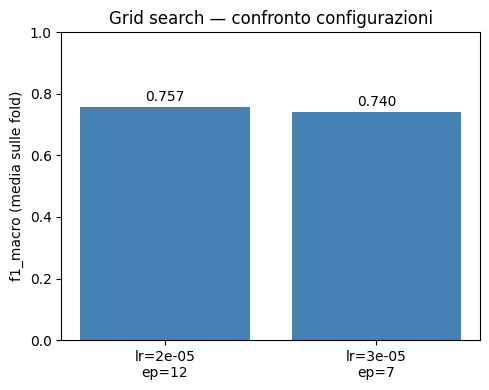

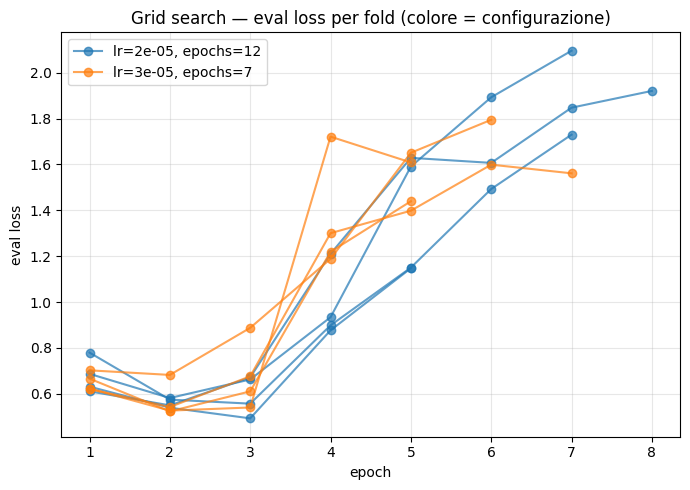

In [13]:
#@title Some Vis. for the grid
fig, ax = plt.subplots(figsize=(5, 4))
labels = [f"lr={r['lr']}\nep={int(r['epochs'])}" for _, r in results_df.iterrows()]
ax.bar(labels, results_df["f1_macro"], color="steelblue")
ax.set_ylabel("f1_macro (media sulle fold)")
ax.set_title("Grid search — confronto configurazioni")
ax.set_ylim(0, 1)
for i, v in enumerate(results_df["f1_macro"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()




def plot_grid_loss_curves(loss_histories, configs):
    """Un'unica figura: una linea per (config, fold), colore = config.
    Utile per vedere se le fold di una stessa config si comportano in modo uniforme."""
    palette = plt.cm.tab10.colors
    color_map = {cfg: palette[i % len(palette)] for i, cfg in enumerate(configs)}
    seen_labels = set()

    fig, ax = plt.subplots(figsize=(7, 5))
    for run in loss_histories:
        cfg = (run["lr"], run["epochs"])
        eval_pts = [(h["epoch"], h["eval_loss"]) for h in run["history"] if "eval_loss" in h]
        if not eval_pts:
            continue
        xs, ys = zip(*eval_pts)
        label = f"lr={cfg[0]}, epochs={cfg[1]}" if cfg not in seen_labels else None
        seen_labels.add(cfg)
        ax.plot(xs, ys, marker="o", alpha=0.7, color=color_map[cfg], label=label)

    ax.set_xlabel("epoch")
    ax.set_ylabel("eval loss")
    ax.set_title("Grid search — eval loss per fold (colore = configurazione)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_grid_loss_curves(loss_histories, configs=GRID)

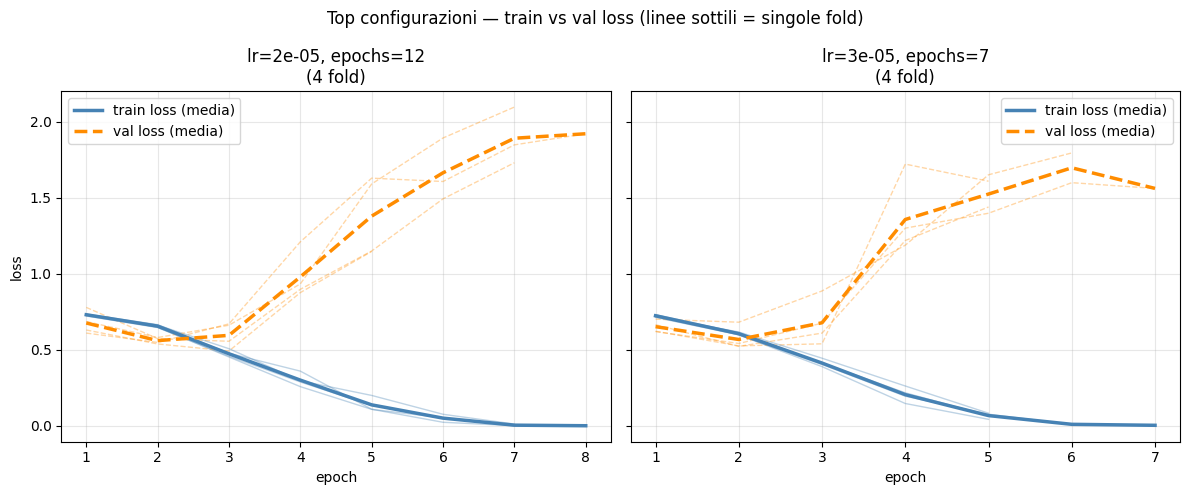

In [14]:
#@title Ancora 1
def plot_top_configs_train_val_loss(loss_histories, results_df, top_n=2):
    top_configs = list(results_df.head(top_n)[["lr", "epochs"]].itertuples(index=False, name=None))

    fig, axes = plt.subplots(1, len(top_configs), figsize=(6 * len(top_configs), 5), sharey=True)
    if len(top_configs) == 1:
        axes = [axes]

    for ax, cfg in zip(axes, top_configs):
        lr, epochs = cfg
        runs = [r for r in loss_histories if (r["lr"], r["epochs"]) == cfg]

        all_train, all_val = [], []
        for run in runs:
            train_pts = [(h["epoch"], h["loss"]) for h in run["history"] if "loss" in h]
            val_pts   = [(h["epoch"], h["eval_loss"]) for h in run["history"] if "eval_loss" in h]

            if train_pts:
                xs, ys = zip(*train_pts)
                ax.plot(xs, ys, color="steelblue", alpha=0.35, linewidth=1)
                all_train.append(pd.Series(ys, index=xs))
            if val_pts:
                xs, ys = zip(*val_pts)
                ax.plot(xs, ys, color="darkorange", alpha=0.35, linewidth=1, linestyle="--")
                all_val.append(pd.Series(ys, index=xs))

        #curva media per epoca (allineata sull'indice epoch)
        if all_train:
            mean_train = pd.concat(all_train, axis=1).mean(axis=1)
            ax.plot(mean_train.index, mean_train.values, color="steelblue", linewidth=2.5, label="train loss (media)")
        if all_val:
            mean_val = pd.concat(all_val, axis=1).mean(axis=1)
            ax.plot(mean_val.index, mean_val.values, color="darkorange", linewidth=2.5, linestyle="--", label="val loss (media)")

        ax.set_title(f"lr={lr}, epochs={epochs}\n({len(runs)} fold)")
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0].set_ylabel("loss")
    fig.suptitle("Top configurazioni — train vs val loss (linee sottili = singole fold)")
    plt.tight_layout()
    plt.show()

plot_top_configs_train_val_loss(loss_histories, results_df, top_n=2)

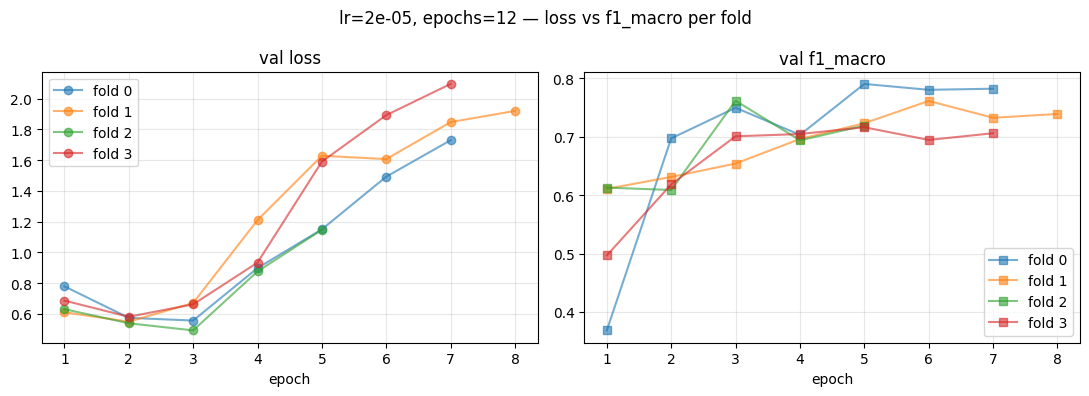

In [15]:
#@title Loss vs macro F1 evolution  per fold
def plot_val_f1_vs_loss(loss_histories, cfg):
    lr, epochs = cfg
    runs = [r for r in loss_histories if (r["lr"], r["epochs"]) == cfg]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for run in runs:
        val_loss_pts = [(h["epoch"], h["eval_loss"]) for h in run["history"] if "eval_loss" in h]
        val_f1_pts   = [(h["epoch"], h["eval_f1_macro"]) for h in run["history"] if "eval_f1_macro" in h]
        if val_loss_pts:
            xs, ys = zip(*val_loss_pts)
            ax1.plot(xs, ys, marker="o", alpha=0.6, label=f"fold {run['fold']}")
        if val_f1_pts:
            xs, ys = zip(*val_f1_pts)
            ax2.plot(xs, ys, marker="s", alpha=0.6, label=f"fold {run['fold']}")

    ax1.set_title("val loss"); ax1.set_xlabel("epoch"); ax1.grid(alpha=0.3); ax1.legend()
    ax2.set_title("val f1_macro"); ax2.set_xlabel("epoch"); ax2.grid(alpha=0.3); ax2.legend()
    fig.suptitle(f"lr={lr}, epochs={epochs} — loss vs f1_macro per fold")
    plt.tight_layout()
    plt.show()

lr_top1, epochs_top1 = results_df.iloc[0][["lr", "epochs"]]
epochs_top1 = int(epochs_top1)

plot_val_f1_vs_loss(loss_histories, cfg=(lr_top1, epochs_top1))

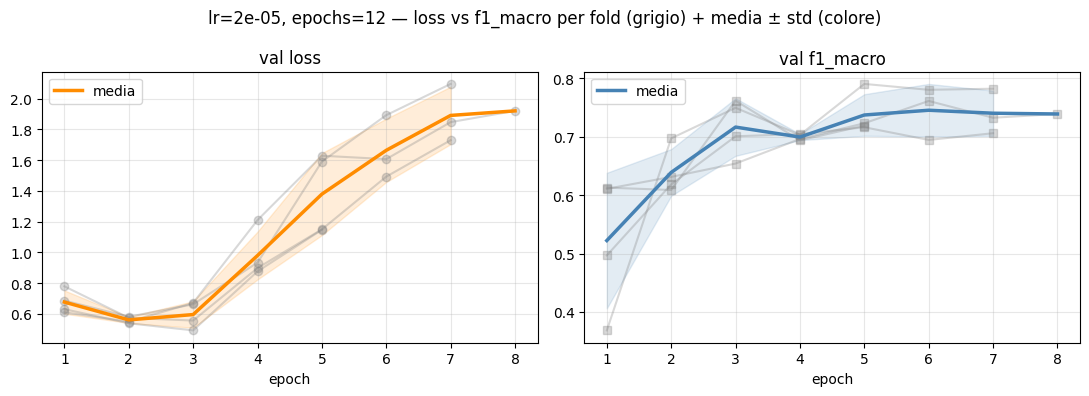

In [16]:
#@title Loss vs macro F1 evolution  per fold
def plot_val_f1_vs_loss(loss_histories, cfg, show_mean=True):
    lr, epochs = cfg
    runs = [r for r in loss_histories if (r["lr"], r["epochs"]) == cfg]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    all_loss, all_f1 = [], []

    for run in runs:
        val_loss_pts = [(h["epoch"], h["eval_loss"]) for h in run["history"] if "eval_loss" in h]
        val_f1_pts   = [(h["epoch"], h["eval_f1_macro"]) for h in run["history"] if "eval_f1_macro" in h]
        if val_loss_pts:
            xs, ys = zip(*val_loss_pts)
            ax1.plot(xs, ys, marker="o", alpha=0.3, color="gray", label=f"fold {run['fold']}" if not show_mean else None)
            all_loss.append(pd.Series(ys, index=xs))
        if val_f1_pts:
            xs, ys = zip(*val_f1_pts)
            ax2.plot(xs, ys, marker="s", alpha=0.3, color="gray", label=f"fold {run['fold']}" if not show_mean else None)
            all_f1.append(pd.Series(ys, index=xs))

    if show_mean:
        if all_loss:
            mean_loss = pd.concat(all_loss, axis=1).mean(axis=1)
            std_loss  = pd.concat(all_loss, axis=1).std(axis=1)
            ax1.plot(mean_loss.index, mean_loss.values, color="darkorange", linewidth=2.5, label="media")
            ax1.fill_between(mean_loss.index, mean_loss - std_loss, mean_loss + std_loss, color="darkorange", alpha=0.15)
        if all_f1:
            mean_f1 = pd.concat(all_f1, axis=1).mean(axis=1)
            std_f1  = pd.concat(all_f1, axis=1).std(axis=1)
            ax2.plot(mean_f1.index, mean_f1.values, color="steelblue", linewidth=2.5, label="media")
            ax2.fill_between(mean_f1.index, mean_f1 - std_f1, mean_f1 + std_f1, color="steelblue", alpha=0.15)

    ax1.set_title("val loss"); ax1.set_xlabel("epoch"); ax1.grid(alpha=0.3); ax1.legend()
    ax2.set_title("val f1_macro"); ax2.set_xlabel("epoch"); ax2.grid(alpha=0.3); ax2.legend()
    fig.suptitle(f"lr={lr}, epochs={epochs} — loss vs f1_macro per fold (grigio) + media ± std (colore)")
    plt.tight_layout()
    plt.show()

plot_val_f1_vs_loss(loss_histories, cfg=(lr_top1, epochs_top1))

## 6. Final fit on the full internal dataset, save for external OOD test

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.7045', 'grad_norm': '18.46', 'learning_rate': '1.783e-05', 'epoch': '1'}
{'loss': '0.5675', 'grad_norm': '10.54', 'learning_rate': '1.338e-05', 'epoch': '2'}
{'loss': '0.3892', 'grad_norm': '7.774', 'learning_rate': '8.93e-06', 'epoch': '3'}
{'loss': '0.2333', 'grad_norm': '103.1', 'learning_rate': '4.482e-06', 'epoch': '4'}
{'loss': '0.1018', 'grad_norm': '0.6342', 'learning_rate': '3.396e-08', 'epoch': '5'}
{'train_runtime': '200.2', 'train_samples_per_second': '26.05', 'train_steps_per_second': '3.272', 'train_loss': '0.3992', 'epoch': '5'}


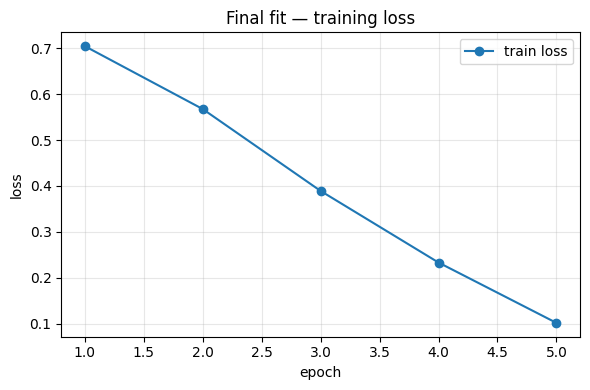

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[saved] ./bert_m02_v2_final
{
  "text_column_used": "text_bert",
  "pretruncated_upstream": true,
  "max_len": 512,
  "sliding_window_enabled": true,
  "classifier_dropout": 0.36,
  "final_lr": 2e-05,
  "final_epochs": 5,
  "grid_results": [
    {
      "lr": 2e-05,
      "epochs": 12,
      "f1_macro": 0.7573896194741698,
      "accuracy": 0.7828865578865579,
      "f1_class0": 0.6790109494814677,
      "f1_class1": 0.8357682894668722,
      "best_epoch_est": 5.0,
      "best_epochs_per_fold": [
        5.0,
        6.0,
        3.0,
        5.0
      ]
    },
    {
      "lr": 3e-05,
      "epochs": 7,
      "f1_macro": 0.7400918979060924,
      "accuracy": 0.7727272727272727,
      "f1_class0": 0.648119918699187,
      "f1_class1": 0.8320638771129978,
      "best_epoch_est": 3.5,
      "best_epochs_per_fold": [
        6.0,
        3.0,
        3.0,
        4.0
      ]
    }
  ]
}


In [25]:
#@title Let's fit and save
FINAL_LR, FINAL_EPOCHS = float(BEST_LR), max(1, round(BEST_EPOCHS))
SAVE_DIR = "./bert_m02_v2_final"

#Fit on all folds of CSV_PATH
full_ds = ds_trainval.remove_columns([c for c in ds_trainval.column_names if c not in MODEL_COLS])

final_args = TrainingArguments(
    output_dir="./_tmp_bert_final",
    learning_rate=FINAL_LR, num_train_epochs=FINAL_EPOCHS,
    per_device_train_batch_size=TRAIN_BS, per_device_eval_batch_size=EVAL_BS,
    weight_decay=0.01, warmup_ratio=0.1, seed=seed,
    eval_strategy="no", save_strategy="no", logging_strategy="epoch",
    disable_tqdm=True, report_to="none",
    fp16=torch.cuda.is_available(),
)

final = WeightedTrainer(
    model=build_model(),
    args=final_args,
    train_dataset=full_ds,
    data_collator=collator,
    class_weights=fold_class_weights(full_ds["labels"], damp=0.5),
)
final.train()
plot_loss_curve(final, title="Final fit — training loss")
final.save_model(SAVE_DIR)
tok.save_pretrained(SAVE_DIR)

import json
run_config_meta = {
    "text_column_used": TEXT_COL,
    "pretruncated_upstream": True,
    "max_len": MAX_LEN,
    "sliding_window_enabled": bool(NEED_SLIDING_WINDOW),
    "classifier_dropout": CLASSIFIER_DROPOUT,
    "final_lr": FINAL_LR,
    "final_epochs": FINAL_EPOCHS,
    "grid_results": results,
}
with open(os.path.join(SAVE_DIR, "run_config.json"), "w") as f:
    json.dump(run_config_meta, f, indent=2)

print(f"[saved] {SAVE_DIR}")
print(json.dumps(run_config_meta, indent=2))

## 7. Held-out test evaluation

In [26]:
#@title Evaluation on test set
test_ds = ds_test.remove_columns([c for c in ds_test.column_names if c not in MODEL_COLS])
test_article_ids = ds_test["article_id"]
test_labels_by_id = (
    pd.DataFrame({"article_id": test_article_ids, "labels": ds_test["labels"]})
    .drop_duplicates("article_id")
    .set_index("article_id")["labels"]
)

test_logits = final.predict(test_ds).predictions
test_metrics = compute_metrics_from_ids(test_logits, test_article_ids, test_labels_by_id)

print(f"[held-out test | external file: {TEST_CSV_PATH}] n_articles={len(test_labels_by_id)}")
print(json.dumps(test_metrics, indent=2))

test_ids_unique, test_preds, test_prob1 = aggregate_predictions(test_logits, test_article_ids)
test_y_true = [test_labels_by_id[i] for i in test_ids_unique]

from sklearn.metrics import classification_report, confusion_matrix
print("\n[classification report]")
print(classification_report(test_y_true, test_preds, target_names=["class0", "class1"], digits=3))
print("[confusion matrix] (rows=true, cols=pred)")
print(confusion_matrix(test_y_true, test_preds))

#Persist test results alongside the rest of the run config saved earlier
run_config_meta["test_source"] = TEST_CSV_PATH
run_config_meta["test_metrics"] = test_metrics
with open(os.path.join(SAVE_DIR, "run_config.json"), "w") as f:
    json.dump(run_config_meta, f, indent=2)
print(f"\n[saved] test metrics appended to {os.path.join(SAVE_DIR, 'run_config.json')}")

[held-out test | external file: /content/test_holdout_processed.csv] n_articles=246
{
  "f1_macro": 0.7147375079063883,
  "accuracy": 0.7317073170731707,
  "f1_class0": 0.6451612903225806,
  "f1_class1": 0.7843137254901961
}

[classification report]
              precision    recall  f1-score   support

      class0      0.577     0.732     0.645        82
      class1      0.845     0.732     0.784       164

    accuracy                          0.732       246
   macro avg      0.711     0.732     0.715       246
weighted avg      0.756     0.732     0.738       246

[confusion matrix] (rows=true, cols=pred)
[[ 60  22]
 [ 44 120]]

[saved] test metrics appended to ./bert_m02_v2_final/run_config.json


## 8. Some other visualizzations

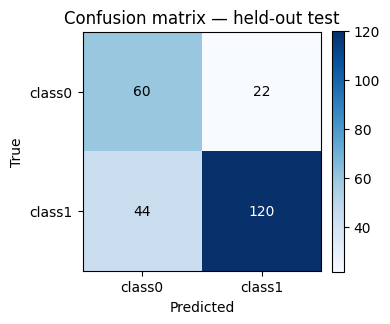

In [27]:
#@title Confusion matrix as heatmap
cm = confusion_matrix(test_y_true, test_preds)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["class0", "class1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["class0", "class1"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — held-out test")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

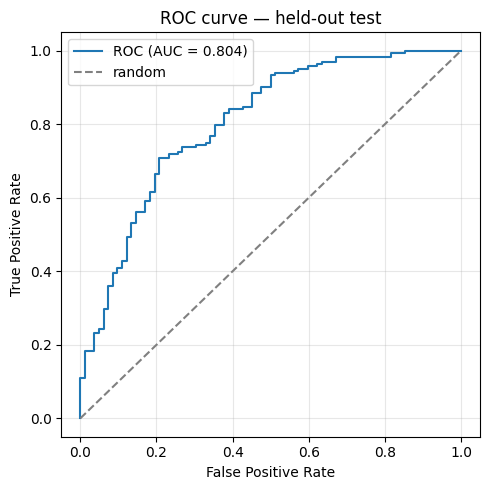

In [28]:
#@title ROC Curve
fpr, tpr, _ = roc_curve(test_y_true, test_prob1)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — held-out test")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

run_config_meta["test_metrics"]["roc_auc"] = float(roc_auc)   # utile da salvare insieme al resto